<a href="https://colab.research.google.com/github/manuelcorrea212/Fisica-Computacional/blob/main/Taller_3_Minimos_Cuadrados_Manuel_Correa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Taller de la semana — Determinación de $g$ con un péndulo

## Propósito

Construir un flujo reproducible que empiece con 100 registros experimentales en Excel, documente la limpieza y termine con un ajuste lineal programado en Fortran 2008.

## Parte A. Limpieza de datos

1. Abra `100_mediciones_pendulo_minimos_cuadrados.xlsx` y revise la hoja `Datos_estudiantes`.
2. Ejecute el script de limpieza suministrado por el profesor.
3. Complete sus tres tareas: correcciones justificadas, elección del ángulo máximo y exclusiones manuales.
4. No excluya un dato únicamente porque se aleja de la tendencia. Toda corrección o exclusión debe apoyarse en la información experimental.
5. El script debe generar `pendulo_limpio.dat` e `informe_limpieza.xlsx`.

## Parte B. Programa en Fortran 2008

Realice el diagrama de flujo respectivo y escriba el programa `ajuste_pendulo.f90`. El programa debe:

1. Abrir `pendulo_limpio.dat` y comprobar que el archivo se abrió correctamente.
2. Leer un número desconocido de filas mediante un ciclo y `iostat`.
3. Convertir cada longitud de centímetros a metros.
4. Calcular $T$ y construir $x=L$ y $y=T^2$.
5. Acumular $N$, $s_x$, $s_y$, $s_{xx}$ y $s_{xy}$.
6. Calcular la pendiente $a$ y el intercepto $b$.
7. Estimar $g=4\pi^2/a$.
8. Realizar una segunda lectura del archivo para calcular $R^2$.
9. Mostrar claramente $N$, $a$, $b$, $R^2$ y $g$, incluyendo unidades.
10. Escribir esos cinco valores, en ese orden y sin encabezado, en `resultados_ajuste.dat`.
11. Detectar al menos estos errores: archivo inexistente, menos de dos datos y denominador nulo.

Para estandarizar el archivo que revisará la celda PASS/FAIL, declare una unidad de salida entera y use al final del programa:

```fortran
open(newunit=unidad_salida, file='resultados_ajuste.dat', &
     status='replace', action='write')
write(unidad_salida, *) n, a, b, r2, g
close(unidad_salida)
```

Compile con advertencias y comprobaciones activadas:

```bash
gfortran -std=f2008 -Wall -Wextra -fcheck=all -o ajuste_pendulo ajuste_pendulo.f90
./ajuste_pendulo
```

## Parte C. Visualización en Python

Complete la celda para representar $T^2$ en función de $L$, la recta calculada con Fortran y los residuos. No use Python para volver a realizar el ajuste: los valores de `a` y `b` deben proceder de su programa Fortran.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Lee las cinco columnas producidas por el script de limpieza
datos = np.loadtxt("pendulo_limpio.dat")
longitud_m = datos[:, 1] / 100.0
numero_oscilaciones = datos[:, 3]
tiempo_total_s = datos[:, 4]

# TODO: construya las variables linealizadas x=L y y=T^2
periodo_s = _____
x = _____
y = _____

# Copie los parámetros calculados por su programa Fortran
a = _____
b = _____

# Ordena x para dibujar una línea continua de izquierda a derecha
orden = np.argsort(x)
y_ajustada = a*x + b
residuos = y - y_ajustada

# Primer panel: mediciones y recta. Segundo panel: residuos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.scatter(x, y, s=25, color="navy", label="Mediciones")
ax1.plot(x[orden], y_ajustada[orden], color="crimson", label="Ajuste Fortran")
ax1.set_xlabel("Longitud L (m)")
ax1.set_ylabel(r"$T^2$ (s$^2$)")
ax1.grid(alpha=0.3)
ax1.legend()

ax2.axhline(0.0, color="black", linewidth=1)
ax2.scatter(x, residuos, s=25, color="darkgreen")
ax2.set_xlabel("Longitud L (m)")
ax2.set_ylabel("Residuo (s²)")
ax2.grid(alpha=0.3)

plt.tight_layout()
# Guarda la figura que se entregará con el informe
plt.savefig("ajuste_pendulo_y_residuos.png", dpi=200, bbox_inches="tight")
plt.show()

## Parte D. Informe de una página

Entregue un informe en PDF usando la plantilla LaTeX suministrada. Debe ocupar **una sola página**. Si el contenido excede una página, resuma las ideas; no reduzca la fuente ni cambie los márgenes.

Use como encabezado: **Taller 3 — Ajuste lineal y péndulo simple**, **Semana 3** y **Lenguajes: Fortran/Python**. Complete las seis secciones de la plantilla:

1. **Contexto físico.** En una o dos frases explique cómo el período de un péndulo permite estimar $g$ y por qué se requiere la aproximación de ángulo pequeño.
2. **Método.** Identifique el ajuste lineal por mínimos cuadrados y presente las relaciones centrales $T^2=(4\pi^2/g)L$ y $g=4\pi^2/a$. No copie el programa completo. Indique brevemente el criterio principal usado para limpiar los datos.
3. **Resultado.** Reporte $g$ frente al valor de referencia $9.81\,\mathrm{m/s^2}$ y su error relativo porcentual. En una frase adicional interprete el intercepto, $R^2$ y el patrón de los residuos. Copie también el resumen de la celda PASS/FAIL.
4. **Obstáculo o decisión de implementación.** Describa un problema concreto encontrado durante la limpieza, lectura del archivo o programación del ajuste, y explique cómo lo resolvió.
5. **Conclusión.** Escriba una o dos frases sobre lo aprendido y una limitación del resultado o del modelo.
6. **Uso de herramientas de IA.** Declare si utilizó IA, cuál herramienta y para qué. Si no utilizó ninguna, indíquelo explícitamente.

Calcule el error relativo porcentual mediante

$$\text{error relativo}=\left|\frac{g_{\mathrm{estimada}}-9.81}{9.81}\right|\times100\%. $$

La figura completa se entrega como archivo separado; no es obligatorio insertarla en el informe de una página.

## Verificación final PASS/FAIL

Para agilizar la revisión, la tarea debe cerrar ejecutando esta celda. La verificación calcula valores de referencia directamente a partir de `pendulo_limpio.dat` y los compara con `resultados_ajuste.dat`. También comprueba que se haya generado la figura.

Un `PASS` indica que el resultado supera esa comprobación automática; no sustituye la revisión de la limpieza, la estructura del programa, las unidades ni la interpretación física.

Solucion del taller

Pregunta A

En esta limpieza de datos, eliminamos datos que tienen un angulo inicial muy grande, (superiores a 15), los datos con registros duplicados y datos que no cuentan con tiempo definido, por ultimo  los que cuentan con observaciones de campo y fallas de seguimiento siendo estos experimentos con los IDs: 12, 18, 36, 45, 47, 60, 68, 73, 77, 88.
Tambien corregimos los datos que tienen justificacion, en este caso un dato con una longitud enorme (700cm) y 2 con tiempos t muy pequeños, siendo estos experimentos identificados con los numeros 52, 23, 81.

In [2]:
!python script_limpieza_pendulo_estudiantes.py


Número inicial de registros: 100

Primeras mediciones:
   medicion_id  longitud_cm  ...  calidad_video  observacion_campo
0            1           55  ...           Alta                NaN
1            2           90  ...           Alta                NaN
2            3           40  ...           Alta                NaN
3            4           75  ...           Alta                NaN
4            5           25  ...           Alta                NaN

[5 rows x 8 columns]

--- RESUMEN DE LIMPIEZA ---
Registros originales: 100
Registros aceptados : 89
Registros excluidos : 11

Archivos generados:
  pendulo_limpio.dat
  informe_limpieza.xlsx


Pregunta B

Realizar un ajuste lineal minimos de cuadros, a partir de los datos limpios de la parte A, para calcular y/o aproximar la aceleracion de la gravedad (G) y el coeficiente R**2






In [3]:
%%writefile ajuste_pendulo.f90
program ajuste_pendulo
  use iso_fortran_env, only: real64, iostat_end  ! Selección de precisión doble y fin de archivo
  implicit none                                  ! Exige declarar todas las variables

 !--------------------- DICCIONARIO DE DATOS ----------------------------------

  ! Constante PI en doble precisión
  real(real64), parameter :: pi = 3.14159265358979323846_real64

  ! Unidades de archivo y código de estado
  integer :: unidad_ent, unidad_salida, estado

  ! Variables leídas del archivo pendulo_limpio.dat (5 columnas)
  integer :: id, n_osc
  real(real64) :: longitud_cm, angulo_deg, tiempo_s

  ! Variables procesadas
  integer :: n_datos
  real(real64) :: L_m, T_s, x, y
  real(real64) :: sx, sy, sxx, sxy, den
  real(real64) :: a, b, g
  real(real64) :: y_prom, y_pred, sse, sst, r2


  ! --------------1. INICIALIZACIÓN DE ACUMULADORES Y CONTADORES--------------

  sx  = 0.0_real64
  sy  = 0.0_real64
  sxx = 0.0_real64
  sxy = 0.0_real64


  !-- 2. PRIMERA PASADA: LECTURA DE DATOS Y CONSTRUCCIÓN DE LAS SUMAS (S_x, S_y, S_xx, S_xy)--

  open(newunit=unidad_ent, file='pendulo_limpio.dat', status='old', &
       action='read', iostat=estado)

  ! Detección de error: archivo inexistente o fallo de apertura
  if (estado /= 0) error stop 'Error: No fue posible abrir el archivo pendulo_limpio.dat'

  do
    ! Lectura de cada fila de 5 columnas
    read(unidad_ent, *, iostat=estado) id, longitud_cm, angulo_deg, n_osc, tiempo_s

    if (estado == iostat_end) exit                     ! Salida normal al llegar al final del archivo
    if (estado /= 0) error stop 'Error de lectura en una fila de pendulo_limpio.dat'

    ! Conversión de unidades: longitud a metros y período en segundos
    L_m = longitud_cm / 100.0_real64
    T_s = tiempo_s / real(n_osc, real64)

    ! Variables linealizadas para el modelo: x = L (m), y = T^2 (s^2)
    x = L_m
    y = T_s**2

    ! Acumuladores de mínimos cuadrados
    n_datos = n_datos + 1
    sx  = sx + x
    sy  = sy + y
    sxx = sxx + x*x
    sxy = sxy + x*y
  end do
  close(unidad_ent)


  !----3. MANEJO DE EXCEPCIONES Y CÁLCULO DE PARÁMETROS DEL AJUSTE (a, b, g)----

  ! Detección de error: menos de dos datos válidos
  if (n_datos < 2) error stop 'Error: Se requieren al menos 2 mediciones para realizar el ajuste'

  ! Denominador del ajuste por mínimos cuadrados
  den = real(n_datos, real64)*sxx - sx*sx

  ! Detección de error: denominador nulo o indeterminado
  if (abs(den) <= tiny(den)) error stop 'Error: Denominador nulo, no se puede calcular la pendiente'

  ! Fórmulas analíticas de mínimos cuadrados
  a = (real(n_datos, real64)*sxy - sx*sy) / den     ! Pendiente a (s^2/m)
  b = (sy - a*sx) / real(n_datos, real64)           ! Intercepto b (s^2)
  g = (4.0_real64 * pi**2) / a                       ! Gravedad estimante g (m/s^2)

  !---4. SEGUNDA PASADA: CÁLCULO DE SSE, SST Y COEFICIENTE DE DETERMINACIÓN R^2---
  y_prom = sy / real(n_datos, real64)
  sse = 0.0_real64
  sst = 0.0_real64

  open(newunit=unidad_ent, file='pendulo_limpio.dat', status='old', &
       action='read', iostat=estado)
  if (estado /= 0) error stop 'Error: Fallo al reabrir pendulo_limpio.dat para calcular R^2'

  do
    read(unidad_ent, *, iostat=estado) id, longitud_cm, angulo_deg, n_osc, tiempo_s
    if (estado == iostat_end) exit

    L_m = longitud_cm / 100.0_real64
    T_s = tiempo_s / real(n_osc, real64)
    x = L_m
    y = T_s**2

    y_pred = a*x + b
    sse = sse + (y - y_pred)**2
    sst = sst + (y - y_prom)**2
  end do
  close(unidad_ent)

  ! Cálculo de R^2
  if (sst > 0.0_real64) then
    r2 = 1.0_real64 - (sse / sst)
  else
    r2 = 0.0_real64
  end if

  !----------5. SALIDA POR PANTALLA CON UNIDADES Y CIFRAS RAZONABLES------------

  print *, "--------------------------------------------------------"
  print *, "       RESULTADOS DEL AJUSTE LINEAL (FORTRAN 2008)      "
  print *, "--------------------------------------------------------"
  print '(A, I0)',        "Número de mediciones (N) : ", n_datos
  print '(A, F12.6, A)',  "Pendiente (a)            : ", a, " s^2/m"
  print '(A, F12.6, A)',  "Intercepto (b)           : ", b, " s^2"
  print '(A, F12.6)',     "Coeficiente (R^2)        : ", r2
  print '(A, F12.6, A)',  "Aceleración de g         : ", g, " m/s^2"
  print *, "--------------------------------------------------------"

  ! ----------------------------------------------------------------------------
  ! 6. ESCRITURA DE ARCHIVO RESULTADOS_AJUSTE.DAT
  ! Estructura obligatoria: N, a, b, R2, g (una fila, sin encabezado)
  ! ----------------------------------------------------------------------------
  open(newunit=unidad_salida, file='resultados_ajuste.dat', &
       status='replace', action='write')
  write(unidad_salida, *) n_datos, a, b, r2, g
  close(unidad_salida)

end program ajuste_pendulo

Writing ajuste_pendulo.f90


In [4]:
!gfortran -std=f2008 -Wall -Wextra -fcheck=all -o ajuste_pendulo ajuste_pendulo.f90
!./ajuste_pendulo

 --------------------------------------------------------
        RESULTADOS DEL AJUSTE LINEAL (FORTRAN 2008)      
 --------------------------------------------------------
Número de mediciones (N) : 89
Pendiente (a)            :     4.048735 s^2/m
Intercepto (b)           :    -0.002888 s^2
Coeficiente (R^2)        :     0.999748
Aceleración de g         :     9.750804 m/s^2
 --------------------------------------------------------


Pregunta C

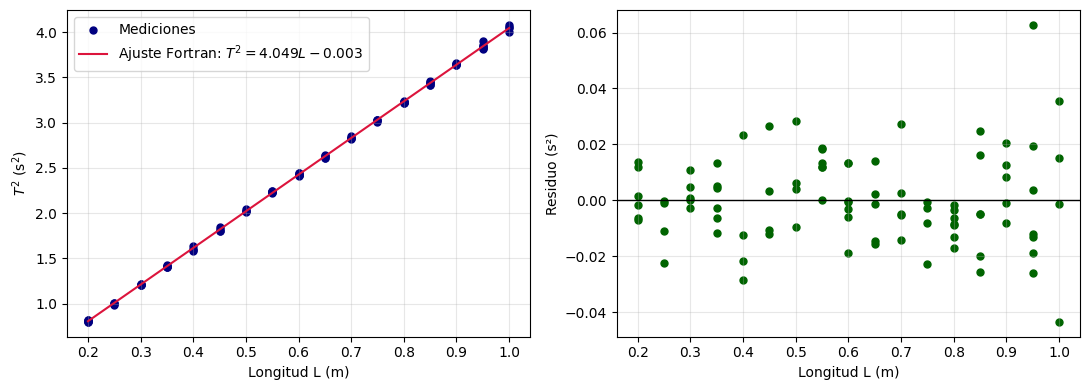


¡Gráfica 'ajuste_pendulo_y_residuos.png' generada y guardada exitosamente!


In [9]:

import numpy as np
import matplotlib.pyplot as plt

# 1. Lee las cinco columnas producidas por el script de limpieza
datos = np.loadtxt("pendulo_limpio.dat")
longitud_m = datos[:, 1] / 100.0
numero_oscilaciones = datos[:, 3]
tiempo_total_s = datos[:, 4]

# Variables linealizadas x=L y y=T^2
periodo_s = tiempo_total_s / numero_oscilaciones
x = longitud_m
y = periodo_s**2

# Carga automática de los parámetros a y b calculados por Fortran
resultados_fortran = np.loadtxt("resultados_ajuste.dat")
a = resultados_fortran[1]
b = resultados_fortran[2]

# Ordena x para dibujar una línea continua de izquierda a derecha
orden = np.argsort(x)
y_ajustada = a * x + b
residuos = y - y_ajustada

# Primer panel: mediciones y recta. Segundo panel: residuos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.scatter(x, y, s=25, color="navy", label="Mediciones")
ax1.plot(x[orden], y_ajustada[orden], color="crimson", label=f"Ajuste Fortran: $T^2 = {a:.3f}L {b:+.3f}$")
ax1.set_xlabel("Longitud L (m)")
ax1.set_ylabel(r"$T^2$ (s$^2$)")
ax1.grid(alpha=0.3)
ax1.legend()

ax2.axhline(0.0, color="black", linewidth=1)
ax2.scatter(x, residuos, s=25, color="darkgreen")
ax2.set_xlabel("Longitud L (m)")
ax2.set_ylabel("Residuo (s²)")
ax2.grid(alpha=0.3)

plt.tight_layout()
# Guarda la figura que se entregará con el informe
plt.savefig("ajuste_pendulo_y_residuos.png", dpi=200, bbox_inches="tight")
plt.show()

print("\n¡Gráfica 'ajuste_pendulo_y_residuos.png' generada y guardada exitosamente!")

Verificación final PASS/FAIL

In [7]:
from pathlib import Path
import numpy as np

# Función auxiliar que imprime un veredicto uniforme para cada prueba
resultados_pruebas = []

def informar(nombre, condicion, detalle=""):
    estado = "PASS" if condicion else "FAIL"
    print(f"{estado:<4}  {nombre}{detalle}")
    resultados_pruebas.append(bool(condicion))
    return bool(condicion)

# Archivos que debe producir el flujo de trabajo completo
archivo_datos = Path("pendulo_limpio.dat")
archivo_resultados = Path("resultados_ajuste.dat")
archivo_figura = Path("ajuste_pendulo_y_residuos.png")

# Primer nivel: comprueba existencia antes de intentar leer
ok_datos = informar("Existe pendulo_limpio.dat", archivo_datos.exists())
ok_resultados = informar("Existe resultados_ajuste.dat", archivo_resultados.exists())
informar("Existe la figura", archivo_figura.exists() and archivo_figura.stat().st_size > 0 if archivo_figura.exists() else False)

# Segundo nivel: valida formatos y compara con un cálculo independiente
if ok_datos and ok_resultados:
    try:
        datos = np.atleast_2d(np.loadtxt(archivo_datos))
        resultados = np.loadtxt(archivo_resultados).reshape(-1)

        estructura_datos = datos.shape[1] == 5 and datos.shape[0] >= 2
        estructura_resultados = resultados.size == 5
        informar("Formato del archivo de datos", estructura_datos, f"  filas={datos.shape[0]}, columnas={datos.shape[1]}")
        informar("Formato del archivo de resultados", estructura_resultados, f"  valores={resultados.size}")

        if estructura_datos and estructura_resultados:
            # Reconstruye x=L y y=T^2 directamente desde los datos limpios
            longitud_m = datos[:, 1] / 100.0
            periodo_s = datos[:, 4] / datos[:, 3]
            x = longitud_m
            y = periodo_s**2
            n_ref = len(x)

            # Calcula los valores de referencia con las fórmulas del método
            sx = np.sum(x)
            sy = np.sum(y)
            sxx = np.sum(x*x)
            sxy = np.sum(x*y)
            den = n_ref*sxx - sx*sx
            a_ref = (n_ref*sxy - sx*sy) / den
            b_ref = (sy - a_ref*sx) / n_ref
            residuos_ref = y - (a_ref*x + b_ref)
            sse_ref = np.sum(residuos_ref**2)
            sst_ref = np.sum((y - np.mean(y))**2)
            r2_ref = 1.0 - sse_ref/sst_ref
            g_ref = 4.0*np.pi**2/a_ref

            # Compara, con tolerancia, cada resultado entregado por Fortran
            n_f, a_f, b_f, r2_f, g_f = resultados
            informar("Número de datos N", int(round(n_f)) == n_ref, f"  obtenido={n_f:g}, esperado={n_ref}")
            informar("Pendiente a", np.isclose(a_f, a_ref, rtol=1e-6, atol=1e-9), f"  obtenida={a_f:.8g}, esperada={a_ref:.8g}")
            informar("Intercepto b", np.isclose(b_f, b_ref, rtol=1e-6, atol=1e-9), f"  obtenido={b_f:.8g}, esperado={b_ref:.8g}")
            informar("Coeficiente R²", np.isclose(r2_f, r2_ref, rtol=1e-6, atol=1e-9), f"  obtenido={r2_f:.8g}, esperado={r2_ref:.8g}")
            informar("Gravedad g", np.isclose(g_f, g_ref, rtol=1e-6, atol=1e-9), f"  obtenida={g_f:.8g}, esperada={g_ref:.8g}")
            informar("Valor físico razonable de g", 7.0 < g_f < 12.0, f"  g={g_f:.5f} m/s²")
    except Exception as error:
        informar("No fue posible completar la verificación", False, f": {error}")

# Resumen que debe copiarse en el informe de una página
n_pass = sum(resultados_pruebas)
n_total = len(resultados_pruebas)
print(f"\nRESUMEN PASS/FAIL: {n_pass} de {n_total} pruebas pasaron.")

PASS  Existe pendulo_limpio.dat
PASS  Existe resultados_ajuste.dat
PASS  Existe la figura
PASS  Formato del archivo de datos  filas=89, columnas=5
PASS  Formato del archivo de resultados  valores=5
PASS  Número de datos N  obtenido=89, esperado=89
PASS  Pendiente a  obtenida=4.0487347, esperada=4.0487347
PASS  Intercepto b  obtenido=-0.0028878571, esperado=-0.0028878571
PASS  Coeficiente R²  obtenido=0.99974782, esperado=0.99974782
PASS  Gravedad g  obtenida=9.7508038, esperada=9.7508038
PASS  Valor físico razonable de g  g=9.75080 m/s²

RESUMEN PASS/FAIL: 11 de 11 pruebas pasaron.
